In [1]:
!pip install plotly

In [56]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
import itertools
import os
import plotly.express as px
import time
from sklearn.metrics.cluster import adjusted_rand_score

In [23]:
sam_mg = SAM()
sam_mg.load_data('SAM_Allen_Institute_MNPO.h5ad')

In [310]:
fn = 'SAM_MO_soupx_plus5_cleaned_MNPO_08182025.h5ad'

sam = SAM()
sam.load_data(fn)

In [311]:
sam.adata

AnnData object with n_obs × n_vars = 1399 × 19307
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_counts', 'n_genes', 'key', 'subclass_id_label_mapping', 'subclass_id_label_lc', 'leiden_clusters', 'subclass_id_label_mapping_nounlabeled', 'neurotransmitter', 'region_label', 'subclass_id_label_reduced_mapping', 'subclass_id_label_reduced_lc', 'subclass_id_label_reduced_mapping_nounlabeled', 'leiden_clusters_formarkers', 'leiden_removal', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5', 'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac', 'eq_subclass_nounlabeled', 'NN', 'ss_subclass', 'ss_subclass_nounlabeled', 'eq_clusters', 'eq_supertype', 'eq_supertype_cl', 'test', 'eq_supertype_cl_v2'
    var: 'mask_genes', 'means', 'variances', 'weights', 'spatial_dispersions'
    uns: 'dimred_indices', 'eq_clusters_colors', 'leiden_clusters_colors', 'path_to_file', 'preprocess_args', 'rank_genes_groups', 'ranked_genes', 'run_args'
    obsm: 'Raw_X', 'X_pc

In [313]:
sam.adata.obs['eq_clusters']

AAAGTCCCAGTCCCGA    4
AAATGGATCATTACCT    2
AACACACGTATCGTTG    3
AAGTGAAAGATACTGA    2
AATAGAGGTGACTGTT    3
                   ..
TTGTGTTCAAGTGGGT    1
TTTACGTCATGGCGCT    0
TTTAGTCTCTTTACAC    0
TTTATGCCACAACGCC    4
TTTCATGGTCTACGTA    1
Name: eq_clusters, Length: 1399, dtype: category
Categories (7, int64): [0, 1, 2, 3, 4, 5, 6]

In [315]:
sam.adata.obs['leiden_clusters']

AAAGTCCCAGTCCCGA    4
AAATGGATCATTACCT    2
AACACACGTATCGTTG    3
AAGTGAAAGATACTGA    2
AATAGAGGTGACTGTT    3
                   ..
TTGTGTTCAAGTGGGT    1
TTTACGTCATGGCGCT    0
TTTAGTCTCTTTACAC    0
TTTATGCCACAACGCC    4
TTTCATGGTCTACGTA    1
Name: leiden_clusters, Length: 1399, dtype: category
Categories (7, int64): [0, 1, 2, 3, 4, 5, 6]

In [314]:
sam.clustering(param = 1)

In [161]:
sm = load_samap('../../Active_SAMap_Joined/sm_hyporirv_mnpo_05202026.pkl')

In [ ]:
sm.sams['mg'].adata.obs['eq_supertype_cl'] = sam_mg.adata.obs['eq_supertype_cl']

In [ ]:
sm.sams['mg'].adata.obs['eq_supertype_cl']

GGAATAATCCTGTACCL8TX_181019_01_D06         MM_3
TGGCGCAGTACATGTCL8TX_181126_01_C11    MM_Thirst
TAAACCGAGTACGATAL8TX_181126_01_C11      MM_Brs3
CATCAGACATCCCACTL8TX_181019_01_D06    MM_Warmth
TAATTCCGTAGCGAGTL8TX_190614_01_B06    MM_Warmth
                                        ...    
TTAGGGTCAGGGAATCL8TX_200903_01_H11      MM_Brs3
TTCCAATAGTACGAGCL8TX_201016_01_E04      MM_Brs3
TTGGGATGTAATGTGAL8TX_201015_01_B03      MM_Brs3
CACAGTAGTTGCGCACL8TX_190423_01_B07         MM_3
TAGGCATCATGCAATCL8TX_180815_01_E08      MM_Brs3
Name: eq_supertype_cl, Length: 2793, dtype: category
Categories (5, object): ['MM_3', 'MM_5', 'MM_Brs3', 'MM_Thirst', 'MM_Warmth']

In [164]:
fin_labels = []
for item in sam_mg.adata.obs['eq_supertype_cl']:
    if item == 'MM_3':
        fin_labels.append('MM_Foxp2_1')
    elif item == 'MM_5':
        fin_labels.append('MM_Foxp2_2')
    else:
        fin_labels.append(item)

In [165]:
sm.sams['mg'].adata.obs['eq_supertype_cl_v2'] = fin_labels
sam_mg.adata.obs['eq_supertype_cl_v2'] = fin_labels

In [316]:
org_two = 'mo'

In [317]:
sm.sams[org_two].clustering(param = 1)

In [318]:
sm.sams['mo'].adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_counts', 'n_genes',
       'key', 'subclass_id_label_mapping', 'subclass_id_label_lc',
       'leiden_clusters', 'subclass_id_label_mapping_nounlabeled',
       'neurotransmitter', 'region_label', 'subclass_id_label_reduced_mapping',
       'subclass_id_label_reduced_lc',
       'subclass_id_label_reduced_mapping_nounlabeled',
       'leiden_clusters_formarkers', 'leiden_removal', 'nCount_SCT',
       'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5',
       'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac',
       'eq_subclass_nounlabeled', 'NN', 'ss_subclass',
       'ss_subclass_nounlabeled', 'eq_clusters', 'eq_supertype',
       'eq_supertype_cl'],
      dtype='object')

In [319]:
keys = {'mg':'eq_supertype_cl_v2',org_two:'leiden_clusters'}
D,MappingTable = get_mapping_scores(sm,keys)

lim_MappingTable = MappingTable.filter(like='mg_')
lim_MappingTable = lim_MappingTable[lim_MappingTable.index.str.contains(org_two + '_')]

/scratch/miniconda/lib/python3.7/site-packages/samap/analysis.py:1609: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  samap.adata.obs[l] = pd.Categorical(cl)


In [320]:
lim_MappingTable

,mg_MM_Brs3,mg_MM_Foxp2_1,mg_MM_Foxp2_2,mg_MM_Thirst,mg_MM_Warmth
mo_0,0.708957,0.000374,0.000000,0.000692,0.014220
mo_1,0.000277,0.002335,0.000176,0.002175,0.799301
mo_2,0.000000,0.012186,0.011374,0.684299,0.142797
mo_3,0.016384,0.010293,0.001579,0.023175,0.663993
mo_4,0.050225,0.634547,0.000000,0.042456,0.002874
mo_5,0.000000,0.634838,0.646408,0.006991,0.000000
mo_6,0.249423,0.000000,0.000000,0.006210,0.340793


In [321]:
fin_mapping = {}
for item in lim_MappingTable.index:
    bm = lim_MappingTable.loc[item,:].idxmax()
    if lim_MappingTable.loc[item,bm] > .4:
        fin_mapping[item] = bm
    else:
        fin_mapping[item] = item
        
fin_labels = []
for item in sam.adata.obs['leiden_clusters']:
    fin_labels.append(fin_mapping[org_two + '_' + str(item)][3:])

In [322]:
sam.adata.obs['test'] = fin_labels

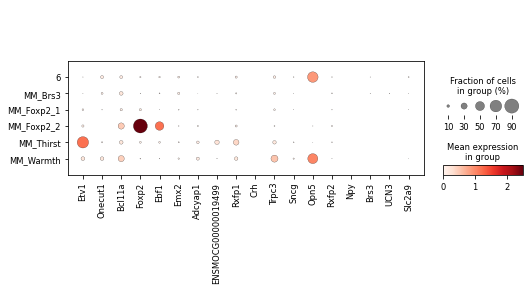

In [324]:
sc.pl.dotplot(sam.adata, groupby='test',var_names=['Etv1','Onecut1','Bcl11a','Foxp2','Ebf1','Emx2','Adcyap1','ENSMOCG00000019499','Rxfp1','Crh','Trpc3','Sncg', 'Opn5','Rxfp2','Npy','Brs3','UCN3','Slc2a9'])

In [300]:
#fin_mapping['ri_1'] = 'mg_MM_Brs3'
#fin_mapping['ri_4'] = 'mg_MM_Brs3'

In [325]:
fin_labels = []
for item in sam.adata.obs['leiden_clusters']:
    fin_labels.append(fin_mapping[org_two + '_' + str(item)][3:])

In [326]:
sam.adata.obs['eq_supertype_cl_v2'] = fin_labels
sm.sams[org_two].adata.obs['eq_supertype_cl_v2'] = fin_labels

In [327]:
sam.adata.obs['eq_supertype_cl']

AAAGTCCCAGTCCCGA    MO_3
AAATGGATCATTACCT    MO_1
AACACACGTATCGTTG    MO_2
AAGTGAAAGATACTGA    MO_1
AATAGAGGTGACTGTT    MO_2
                    ... 
TTGTGTTCAAGTGGGT    MO_2
TTTACGTCATGGCGCT    MO_4
TTTAGTCTCTTTACAC    MO_4
TTTATGCCACAACGCC    MO_3
TTTCATGGTCTACGTA    MO_2
Name: eq_supertype_cl, Length: 1399, dtype: category
Categories (5, object): ['MO_1', 'MO_2', 'MO_3', 'MO_4', 'MO_5']

In [328]:
sam.adata.obs['eq_supertype_cl_v2']

AAAGTCCCAGTCCCGA    MM_Foxp2_1
AAATGGATCATTACCT     MM_Thirst
AACACACGTATCGTTG     MM_Warmth
AAGTGAAAGATACTGA     MM_Thirst
AATAGAGGTGACTGTT     MM_Warmth
                       ...    
TTGTGTTCAAGTGGGT     MM_Warmth
TTTACGTCATGGCGCT       MM_Brs3
TTTAGTCTCTTTACAC       MM_Brs3
TTTATGCCACAACGCC    MM_Foxp2_1
TTTCATGGTCTACGTA     MM_Warmth
Name: eq_supertype_cl_v2, Length: 1399, dtype: object

In [329]:
adjusted_rand_score(sam.adata.obs['eq_supertype_cl_v2'], sam.adata.obs['eq_supertype_cl'])

0.8548278692956962

In [330]:
sam.adata.obs['eq_clusters_v2'] = sm.sams['mo'].adata.obs['leiden_clusters']
sm.sams['mo'].adata.obs['eq_clusters_v2'] = sm.sams['mo'].adata.obs['leiden_clusters']

In [331]:
sam.save_anndata(fn)

In [332]:
save_samap(sm,'../../Active_SAMap_Joined/sm_hyporirv_mnpo_05202026.pkl')